## Image Segmentation
Part 1 of image segment analysis, segmenting images with Python. Code from opensourceoptions.com resources and tutorial. https://opensourceoptions.com/python-geographic-object-based-image-analysis-geobia/

In [40]:
# Importing Packages
import numpy as np
import pandas as pd
from skimage import exposure
from skimage.segmentation import quickshift, slic, mark_boundaries
import time
import scipy
import matplotlib.pyplot as plt
from osgeo import gdal
from osgeo import ogr
from osgeo import osr
from osgeo import gdal_array
import os
import geopandas as gpd
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier

In [12]:
os.chdir('/home/jovyan/project/trees_n_shrimps')
camau2026_fn = 'ca_mau_2026_48PVQ.tif'
camau2017_fn = 'ca_mau_2017_48PVQ.tif'
# verify files exist
for fn in [camau2026_fn, camau2017_fn]:
    print(fn, 'exists:', os.path.exists(fn))

In [13]:
# Open the dataset 2026
driverTiff = gdal.GetDriverByName('GTiff')
camau2026_ds = gdal.Open(camau2026_fn)

# Check it opened correctly
if camau2026_ds is None:
    raise FileNotFoundError(f"Could not open file: {camau2026_fn}")

nbands = camau2026_ds.RasterCount
print('bands', camau2026_ds.RasterCount, 'rows', camau2026_ds.RasterYSize, 'columns', camau2026_ds.RasterXSize)

# Read all bands into a stacked array
band_data2026 = []
for i in range(1, nbands + 1):
    band = camau2026_ds.GetRasterBand(i).ReadAsArray()
    band_data2026.append(band)

band_data2026 = np.dstack(band_data2026)
band_data2026 = np.nan_to_num(band_data2026, nan=np.nanmedian(band_data2026))
print('Array shape:', band_data2026.shape)  # (rows, cols, bands)

bands 7 rows 1660 columns 2202
Array shape: (1660, 2202, 7)


In [14]:
# Open the dataset 2017
driverTiff = gdal.GetDriverByName('GTiff')
camau2017_ds = gdal.Open(camau2017_fn)

# Check it opened correctly
if camau2017_ds is None:
    raise FileNotFoundError(f"Could not open file: {camau2017_fn}")

nbands = camau2017_ds.RasterCount
print('bands', camau2017_ds.RasterCount, 'rows', camau2017_ds.RasterYSize, 'columns', camau2017_ds.RasterXSize)

# Read all bands into a stacked array
band_data2017 = []
for i in range(1, nbands + 1):
    band = camau2017_ds.GetRasterBand(i).ReadAsArray()
    band_data2017.append(band)

band_data2017 = np.dstack(band_data2017)
band_data2017 = np.nan_to_num(band_data2017, nan=np.nanmedian(band_data2017))

print('Array shape:', band_data2017.shape)  # (rows, cols, bands)

bands 7 rows 1660 columns 2202
Array shape: (1660, 2202, 7)


In [15]:
# Segmentation done using scikit-image. 2026

# scale image values from 0.0 - 1.0
img2026 = exposure.rescale_intensity(band_data2026)

# do segmentation multiple options with quickshift and slic
# figure out which option works best (see examples right below)
seg_start = time.time()
# segments = quickshift(img, convert2lab=False)
# segments = quickshift(img, ratio=0.8, convert2lab=False)
# segments = quickshift(img, ratio=0.99, max_dist=5, convert2lab=False)
# segments = slic(img, n_segments=100000, compactness=0.1)
# segments = slic(img, n_segments=500000, compactness=0.01)
segments2026 = slic(img2026, n_segments=50000, compactness=0.1)
print('segments complete', time.time() - seg_start)

# save segments to raster
segments2026_fn = 'segments2026.tif'
segments2026_ds = driverTiff.Create(segments2026_fn, camau2026_ds.RasterXSize, camau2026_ds.RasterYSize,
                                1, gdal.GDT_Float32)
segments2026_ds.SetGeoTransform(camau2026_ds.GetGeoTransform())
segments2026_ds.SetProjection(camau2026_ds.GetProjectionRef())
segments2026_ds.GetRasterBand(1).WriteArray(segments2026)
segments2026_ds = None

print('Unique segments 2026:', len(np.unique(segments2026)))
print('Image shape 2026:', img2026.shape)
print('Segments shape 2026:', segments2026.shape)
print('Segments min/max 2026:', segments2026.min(), segments2026.max())

segments complete 5.119034051895142
Unique segments 2026: 35065
Image shape 2026: (1660, 2202, 7)
Segments shape 2026: (1660, 2202)
Segments min/max 2026: 1 35065


In [16]:
# Segmentation done using scikit-image. 2017

# scale image values from 0.0 - 1.0
img2017 = exposure.rescale_intensity(band_data2017)



# do segmentation multiple options with quickshift and slic
# figure out which option works best (see examples right below)
seg_start = time.time()
# segments = quickshift(img, convert2lab=False)
# segments = quickshift(img, ratio=0.8, convert2lab=False)
# segments = quickshift(img, ratio=0.99, max_dist=5, convert2lab=False)
# segments = slic(img, n_segments=100000, compactness=0.1)
# segments = slic(img, n_segments=500000, compactness=0.01)
segments2017 = slic(img2017, n_segments=50000, compactness=0.1)
print('segments complete', time.time() - seg_start)

# save segments to raster
segments2017_fn = 'segments2017.tif'
segments2017_ds = driverTiff.Create(segments2017_fn, camau2017_ds.RasterXSize, camau2017_ds.RasterYSize,
                                1, gdal.GDT_Float32)
segments2017_ds.SetGeoTransform(camau2017_ds.GetGeoTransform())
segments2017_ds.SetProjection(camau2017_ds.GetProjectionRef())
segments2017_ds.GetRasterBand(1).WriteArray(segments2017)
segments2017_ds = None

print('Unique segments 2017:', len(np.unique(segments2017)))
print('Image shape 2017:', img2017.shape)
print('Segments shape 2017:', segments2017.shape)
print('Segments min/max 2017:', segments2017.min(), segments2017.max())

segments complete 7.66260027885437
Unique segments 2017: 37325
Image shape 2017: (1660, 2202, 7)
Segments shape 2017: (1660, 2202)
Segments min/max 2017: 1 37325


Text(0.5, 1.0, '2026 Segmentation result: 35065 segments')

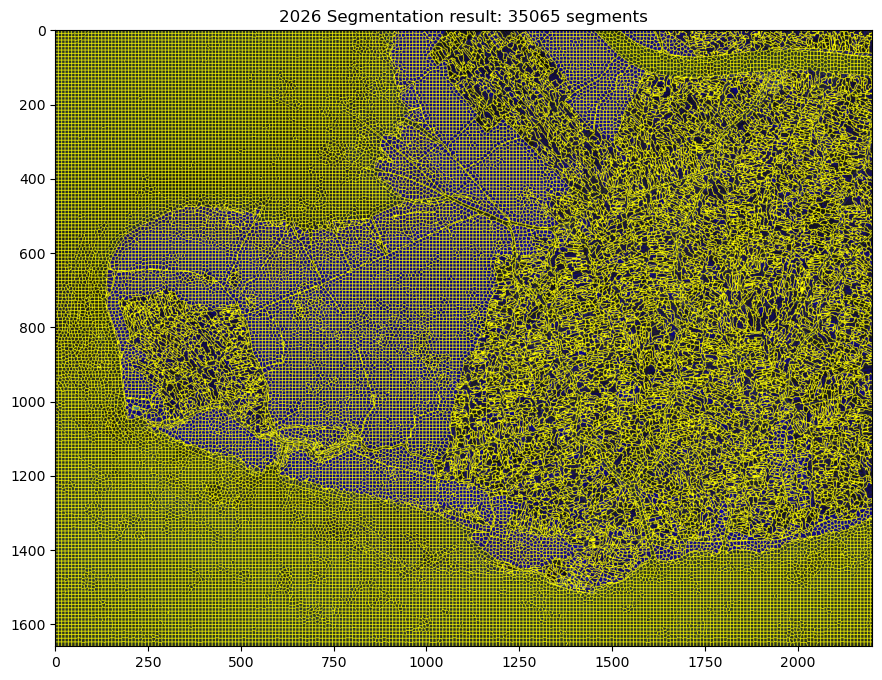

In [17]:
rgb = exposure.rescale_intensity(band_data2026[:, :, :3].astype(float))
plt.figure(figsize=(12, 8))
plt.imshow(mark_boundaries(rgb, segments2026))
plt.title(f'2026 Segmentation result: {len(np.unique(segments2026))} segments')

Text(0.5, 1.0, '2017 Segmentation result: 37325 segments')

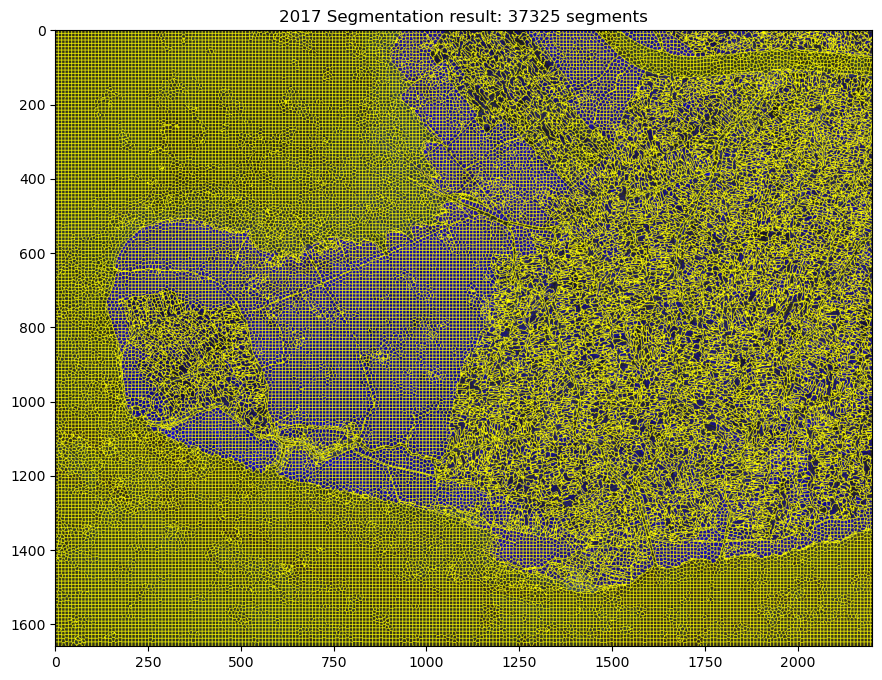

In [18]:
rgb = exposure.rescale_intensity(band_data2017[:, :, :3].astype(float))
plt.figure(figsize=(12, 8))
plt.imshow(mark_boundaries(rgb, segments2017))
plt.title(f'2017 Segmentation result: {len(np.unique(segments2017))} segments')

In [19]:
# Describing each segment based on spectral properties: 
# spectral properties = variables that will classify each segment as a land cover type.

# Function that returns the min, max, mean, variance, skewness, and kurtois for each band in a given array of pixels.
def segment_features(segment_pixels):
    features = []
    npixels, nbands = segment_pixels.shape
    for b in range(nbands):
        stats = scipy.stats.describe(segment_pixels[:, b])
        band_stats = list(stats.minmax) + list(stats)[2:]
        if npixels == 1:
            # in this case the variance = nan, change it 0.0
            band_stats[3] = 0.0
        features += band_stats
    return features

In [20]:
# Makes a list of segment ID numbers and the pixels for each are passed to segment_features.
# Statistics from segment_features are stored in objects list, and object_id stored in a separate list.
# May take several hours to run, depending on setup. 
#Note from Will- actually didn't take that long to run, maybe 15 mins

segment2026_ids = np.unique(segments2026)
objects2026 = []
object_ids2026 = []
for id in segment2026_ids:
    segment_pixels = img2026[segments2026 == id]
    object_features = segment_features(segment_pixels)
    objects2026.append(object_features)
    object_ids2026.append(id)

In [21]:
segment2017_ids = np.unique(segments2017)
objects2017 = []
object_ids2017 = []
for id in segment2017_ids:
    segment_pixels = img2017[segments2017 == id]
    object_features = segment_features(segment_pixels)
    objects2017.append(object_features)
    object_ids2017.append(id)

In [22]:
#Create pandas dataframe, set segment ID as index
df_camau_2026 = pd.DataFrame(objects2026)
df_camau_2026["segment_id"] = object_ids2026
df_camau_2026 = df_camau_2026.set_index("segment_id")

In [23]:
#Create pandas dataframe, set segment ID as index
df_camau_2017 = pd.DataFrame(objects2017)
df_camau_2017["segment_id"] = object_ids2017
df_camau_2017 = df_camau_2017.set_index("segment_id")

In [27]:
#Give column names from stats and bands; number of columns = # stats x # bands
stats = ["min","max","mean","var","skew","kurt"]
bands = ["B03","B04","B08","B11","NDVI","NDWI","CMRI"]

columns2026 = []
for b in bands:
    for s in stats:
        columns2026.append(f"{b}_{s}")

df_camau_2026.columns = columns2026

In [28]:
columns2017 = []
for b in bands:
    for s in stats:
        columns2017.append(f"{b}_{s}")

df_camau_2017.columns = columns2017

In [31]:
# read shapefile to geopandas geodataframe
gdf2017 = gpd.read_file('camau_2017trainingobject.shp')

In [32]:
class_names = gdf2017['Class'].unique()
class_ids = gdf2017['Class_ID'].unique()
print('class names', class_names)
print('class ids', class_ids)

# save lookup table
df2017 = pd.DataFrame({'label': class_names, 'id': class_ids})
df2017.to_csv('class_lookup2017.csv', index=False)

# map IDs onto geodataframe
gdf2017['id'] = gdf2017['Class'].map(dict(zip(class_names, class_ids)))
print('gdf with ids', gdf2017.head())

# 70/30 train/test split
gdf_train2017 = gdf2017.sample(frac=0.7, random_state=42)
gdf_test2017 = gdf2017.drop(gdf_train2017.index)
print('gdf shape', gdf2017.shape, 'training shape', gdf_train2017.shape, 'test', gdf_test2017.shape)

gdf_train2017.to_file('gdf_train2017.shp')
gdf_test2017.to_file('gdf_test2017.shp')

class names ['Water' 'Mangrove-integrated pond' 'Pond' 'Mangrove' 'Built up/bare']
class ids [1 2 3 4 5]
gdf with ids    Id  Class  Class_ID                                           geometry  id
0   0  Water         1  POLYGON ((479877.738 956396.259, 480084.193 95...   1
1   0  Water         1  POLYGON ((478526.77 956786.375, 478844.382 956...   1
2   0  Water         1  POLYGON ((484741.927 958368.309, 484786.336 95...   1
3   0  Water         1  POLYGON ((483665.472 955345.702, 483692.538 95...   1
4   0  Water         1  POLYGON ((483824.942 953964.727, 483914.527 95...   1
gdf shape (120, 5) training shape (84, 5) test (36, 5)


/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'id' to 'id_1'
  ogr_write(
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'id' to 'id_1'
  ogr_write(


In [33]:

# Open your training polygons
train_fn2017 = 'gdf_train2017.shp'
train_ds2017 = ogr.Open(train_fn2017)
lyr2017 = train_ds2017.GetLayer()

# Check what fields are available
lyr_defn = lyr2017.GetLayerDefn()
field_names = [lyr_defn.GetFieldDefn(i).GetName() for i in range(lyr_defn.GetFieldCount())]
print('Available fields:', field_names)

# Create raster in memory
driver = gdal.GetDriverByName('MEM')
target_ds2017 = driver.Create('', camau2017_ds.RasterXSize, camau2017_ds.RasterYSize, 1, gdal.GDT_UInt16)
target_ds2017.SetGeoTransform(camau2017_ds.GetGeoTransform())
target_ds2017.SetProjection(camau2017_ds.GetProjection())

# Rasterize using 'Class_ID'
options = ['ATTRIBUTE=Class_ID']
gdal.RasterizeLayer(target_ds2017, [1], lyr2017, options=options)

data2017 = target_ds2017.GetRasterBand(1).ReadAsArray()
print('min', data2017.min(), 'max', data2017.max())
print('Unique classes rasterized:', np.unique(data2017))

Available fields: ['Id', 'Class', 'Class_ID', 'id_1']
min 0 max 5
Unique classes rasterized: [0 1 2 3 4 5]


In [35]:
ground_truth2017 = target_ds2017.GetRasterBand(1).ReadAsArray()
classes = np.unique(ground_truth2017)[1:] 
print('class values', classes)

segments_per_class2017 = {}
for klass in classes:
    segments_of_class = segments2017[ground_truth2017 == klass]  
    segments_per_class2017[klass] = set(segments_of_class)       
    print("Training segments for class", klass, ":", len(segments_of_class))

intersection = set()
accum = set()
for class_segments in segments_per_class2017.values():
    intersection |= accum.intersection(class_segments)
    accum |= class_segments

print(f"Removing {len(intersection)} ambiguous segments that span multiple classes")

# remove conflicted segments from all classes
segments_per_class2017_clean = {}
for klass in classes:
    segments_per_class2017_clean[klass] = segments_per_class2017[klass] - intersection
    print(f"Class {klass}: {len(segments_per_class2017[klass])} -> {len(segments_per_class2017_clean[klass])} segments after cleaning")

segments_per_class2017 = segments_per_class2017_clean

intersection = set()
accum = set()
for class_segments in segments_per_class2017.values():
    intersection |= accum.intersection(class_segments)
    accum |= class_segments
assert len(intersection) == 0, "Segment(s) represent multiple classes"

class values [1 2 3 4 5]
Training segments for class 1 : 12622
Training segments for class 2 : 15860
Training segments for class 3 : 9247
Training segments for class 4 : 15267
Training segments for class 5 : 719
Removing 1 ambiguous segments that span multiple classes
Class 1: 221 -> 221 segments after cleaning
Class 2: 311 -> 310 segments after cleaning
Class 3: 181 -> 180 segments after cleaning
Class 4: 283 -> 283 segments after cleaning
Class 5: 25 -> 25 segments after cleaning


In [47]:
### Classify the Image
train_img2017 = np.copy(segments2017)
threshold = train_img2017.max() + 1
for klass in classes:
    class_label = threshold + klass
    for segment_id in segments_per_class2017[klass]:
        train_img2017[train_img2017 == segment_id] = class_label
train_img2017[train_img2017 <= threshold] = 0
train_img2017[train_img2017 > threshold] -= threshold

segment_ids = object_ids2017
objects = objects2017

training_objects = []
training_labels = []
for klass in classes:
    class_train_object = [v for i, v in enumerate(objects) if segment_ids[i] in segments_per_class2017[klass]]
    training_labels += [klass] * len(class_train_object)
    training_objects += class_train_object
    print('Training objects for class', klass, ':', len(class_train_object))

classifier = RandomForestClassifier(n_jobs=-1)
classifier.fit(training_objects, training_labels)
print('Fitting Random Forest Classifier')

predicted = classifier.predict(objects)
print('Predicting Classifications')

clf2017 = np.copy(segments2017)
for segment_id, klass in zip(segment_ids, predicted):
    clf2017[clf2017 == segment_id] = klass
print('Prediction applied to numpy array')

nodata_val = camau2017_ds.GetRasterBand(1).GetNoDataValue()
print('Nodata value:', nodata_val)
nodata_mask = (band_data2017[:,:,0] == nodata_val)  # mask where first band == nodata
clf2017[nodata_mask] = -9999.0

print('Saving classification to raster with gdal')
clfds2017 = driverTiff.Create('classified_2017_try1.tif', camau2017_ds.RasterXSize, camau2017_ds.RasterYSize,
                          1, gdal.GDT_Float32)
clfds2017.SetGeoTransform(camau2017_ds.GetGeoTransform())
clfds2017.SetProjection(camau2017_ds.GetProjection())
clfds2017.GetRasterBand(1).SetNoDataValue(-9999.0)
clfds2017.GetRasterBand(1).WriteArray(clf2017)
clfds2017 = None
print('Done!')

Training objects for class 1 : 221
Training objects for class 2 : 310
Training objects for class 3 : 180
Training objects for class 4 : 283
Training objects for class 5 : 25
Fitting Random Forest Classifier
Predicting Classifications
Prediction applied to numpy array
Nodata value: None
Saving classification to raster with gdal
Done!
